In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
data=pd.read_csv("/content/uber.csv")
data.shape
print(data.head())
print(data.info())
print(data.describe())

   Unnamed: 0      key  fare_amount          pickup_datetime  \
0    24238194  52:06.0          7.5  2015-05-07 19:52:06 UTC   
1    27835199  04:56.0          7.7  2009-07-17 20:04:56 UTC   
2    44984355  45:00.0         12.9  2009-08-24 21:45:00 UTC   
3    25894730  22:21.0          5.3  2009-06-26 08:22:21 UTC   
4    17610152  47:00.0         16.0  2014-08-28 17:47:00 UTC   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.999817        40.738354         -73.999512         40.723217   
1        -73.994355        40.728225         -73.994710         40.750325   
2        -74.005043        40.740770         -73.962565         40.772647   
3        -73.976124        40.790844         -73.965316         40.803349   
4        -73.925023        40.744085         -73.973082         40.761247   

   passenger_count  
0                1  
1                1  
2                1  
3                3  
4                5  
<class 'pandas.core.frame.

In [ ]:
 #Drop irrelevant columns
data = data.drop(columns=["Unnamed: 0", "key"])
data.isnull().sum()
#remove missing
data.isnull().sum()
data = data.dropna()
data.shape

(199999, 7)

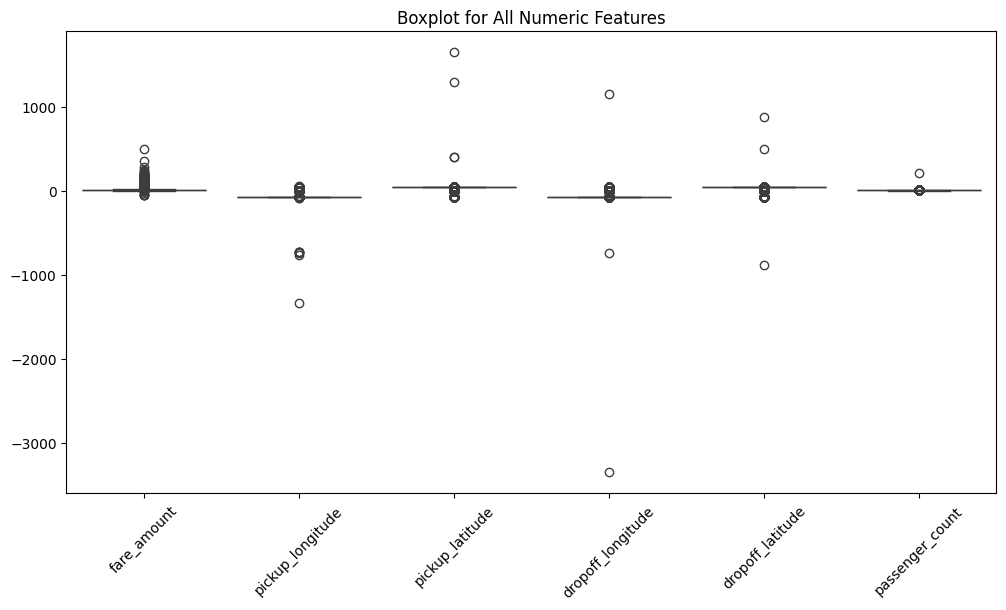

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title("Boxplot for All Numeric Features")
plt.xticks(rotation=45)
plt.show()

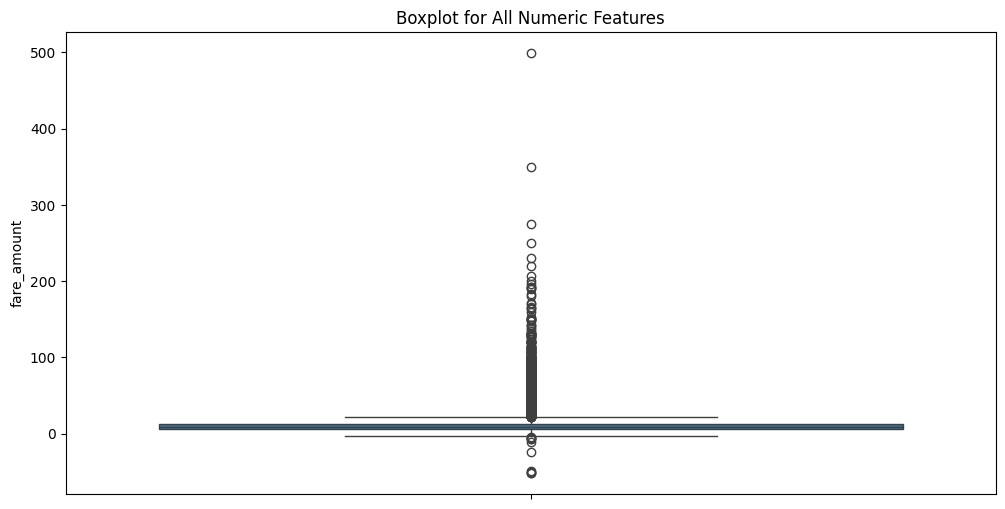

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data['fare_amount'])
plt.title("Boxplot for All Numeric Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def remove_outliers(data):
    numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Keep only rows within the bounds
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data

# Apply the function
df_clean = remove_outliers(data)

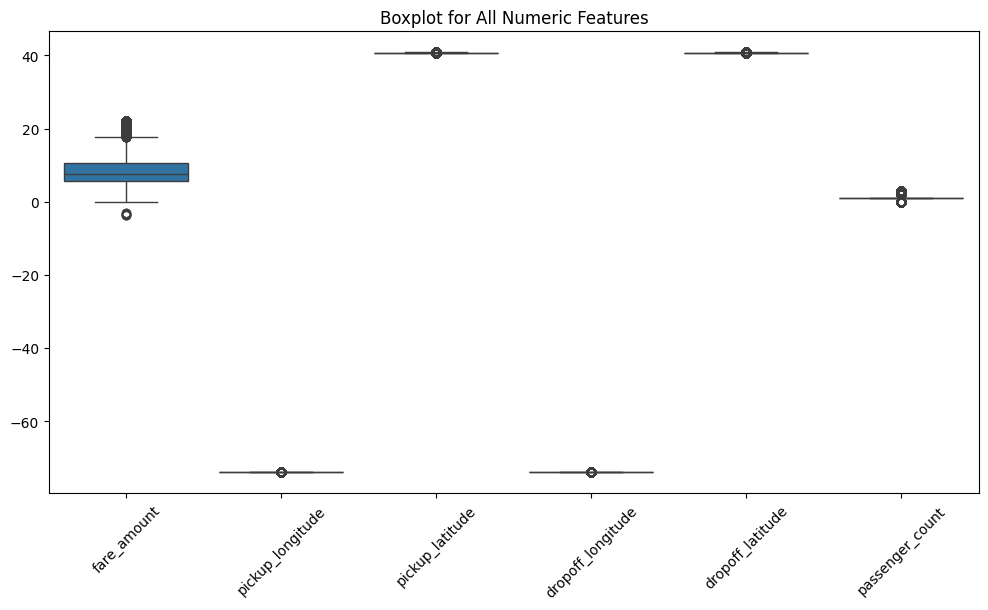

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean)
plt.title("Boxplot for All Numeric Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
data.shape
df_clean.shape

(148075, 7)

In [ ]:
# Convert datetime
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["hour"] = data["pickup_datetime"].dt.hour
data["day"] = data["pickup_datetime"].dt.day
data["month"] = data["pickup_datetime"].dt.month
data["weekday"] = data["pickup_datetime"].dt.weekday
data = data.drop(columns=["pickup_datetime"])
data['is_peak']=data['hour'].apply(lambda x:1 if x in [8,9,17,18,19] else 0)
data['is_surge']=(data['fare_amount'] > data['fare_amount'].quantile(0.75)).astype(int)
data.head()
data.to_csv("/content/uber_cleaned.csv", index=False)
print("✅ Saved! Columns:", list(data.columns))

✅ Saved! Columns: ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'weekday', 'is_peak', 'is_surge']


In [ ]:
# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    #differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    #Haversine formula
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    #The Haversine formula calculates the great-circle distance between two points on the Earth given their latitude and longitude.
    # This is the shortest distance over the Earth’s surface (as the Earth is roughly spherical).

    # Distance is returned in kilometers because we multiply by 6371 (Earth radius in km)
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

In [ ]:
data["distance_km"] = haversine(
    data["pickup_latitude"], data["pickup_longitude"],
    data["dropoff_latitude"], data["dropoff_longitude"]
)

In [ ]:
# Remove unrealistic values
data = data[(data["fare_amount"] > 0) & (data["fare_amount"] < 200)]
data = data[(data["distance_km"] > 0) & (data["distance_km"] < 100)]
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] < 7)]
data.shape

(193188, 13)

In [ ]:
X = data[["distance_km", "passenger_count", "hour", "day", "month", "weekday","is_peak"]]
y = data["fare_amount"]

In [ ]:
data.tail()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,is_peak,is_surge,distance_km
199995,3.0,-73.987042,40.739367,-73.986525,40.740297,1,10,28,10,6,0,0,0.112210
199996,7.5,-73.984722,40.736837,-74.006672,40.739620,1,1,14,3,4,0,0,1.875050
199997,30.9,-73.986017,40.756487,-73.858957,40.692588,2,0,29,6,0,0,1,12.850319
199998,14.5,-73.997124,40.725452,-73.983215,40.695416,1,14,20,5,2,0,1,3.539715
199999,14.1,-73.984395,40.720077,-73.985508,40.768793,1,4,15,5,5,0,1,5.417783


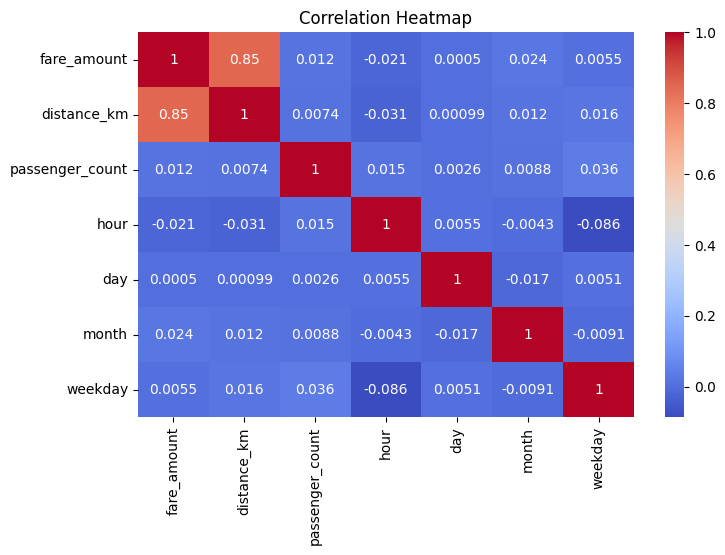

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(data[["fare_amount","distance_km","passenger_count","hour","day","month","weekday"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

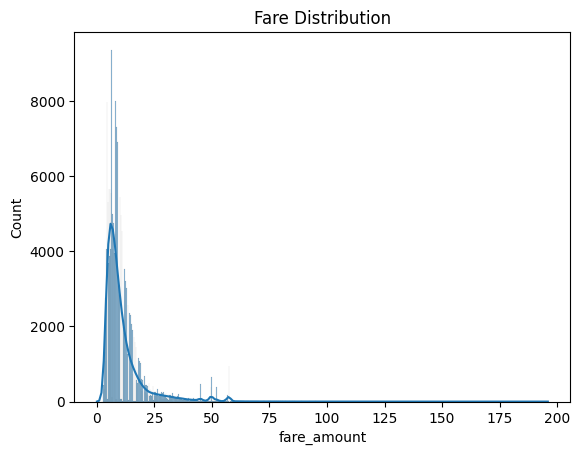

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data['fare_amount'], kde=True)
plt.title("Fare Distribution")
plt.show()

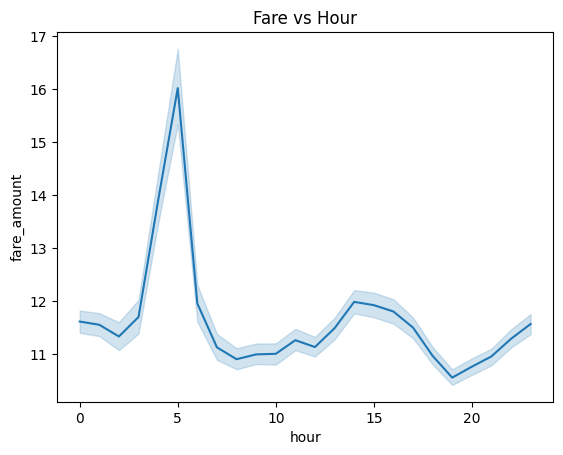

In [ ]:
sns.lineplot(x='hour', y='fare_amount', data=data)
plt.title("Fare vs Hour")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# RFR Model
rf = RandomForestRegressor(n_estimators=200, max_depth=10,random_state=42,n_jobs=-1)
# Train
rf.fit(X_train, y_train)
# Predict
y_pred = rf.predict(X_test)
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.2387293084408055
MSE: 19.25861084405877
RMSE: 4.388463380735764
R2 Score: 0.7902857278518441


In [ ]:
# Step 5: Initialize model
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

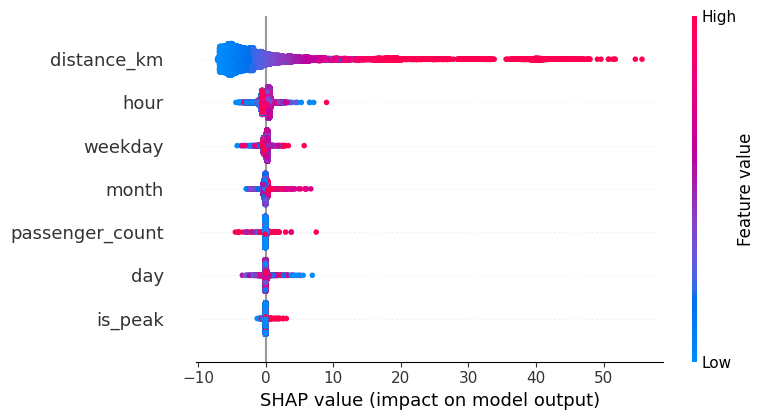

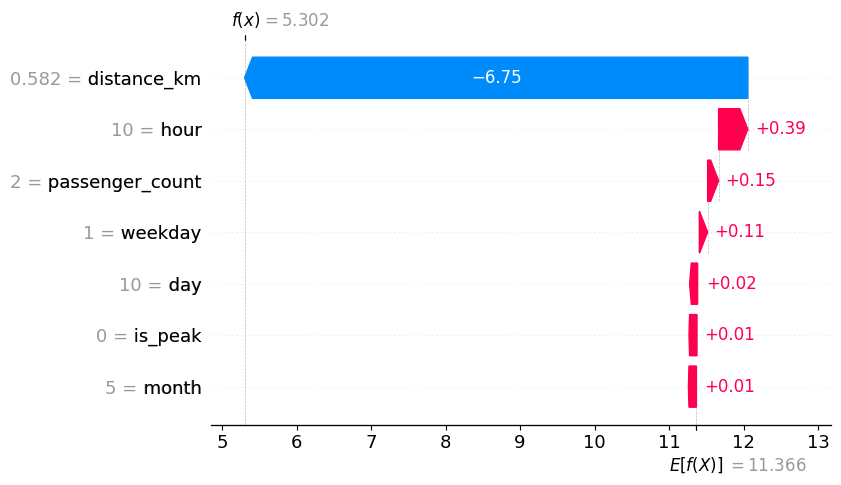

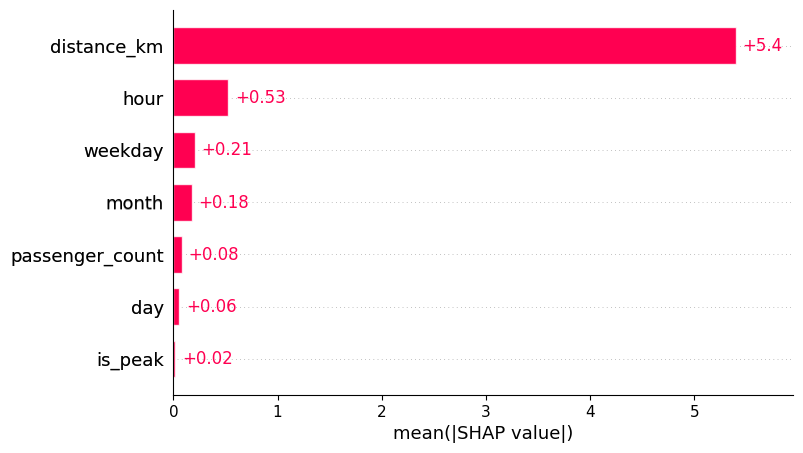

In [ ]:
# Step 6: Train model
xgb.fit(X_train, y_train)
# Step 7: Import SHAP
import shap
# Step 8: Create explainer
explainer = shap.Explainer(xgb)
# Step 9: Calculate SHAP values
shap_values = explainer(X_test)
# Step 10: Global feature importance (summary plot)
shap.summary_plot(shap_values, X_test)
# Step 11: Individual prediction explanation (waterfall)
shap.plots.waterfall(shap_values[0])
shap.plots.bar(shap_values)